# Notes
Helpful info from udemy course: 
https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb

# GitHub Repository:
https://github.com/mpennino/Future_DW_NO3

In [254]:
# Import libraries
import pandas as pd
import torch
import torch.nn as nn

import pyarrow as pa
import pyarrow.parquet as pq


In [255]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [256]:
# Load Observation Dataset
# DATA = readRDS(paste0(strap_dir,'Data/Models/RF_bi_model_All_DATA_all_vars_','Trends_Conc_PWS_GW_05to20', '.rds'))
#future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_Future_DW/Data/'
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'

#dataset1 = 'Dataset_RF_Model_SW_HUC12.csv'
dataset1 = 'Dataset_RF_Model_GW_HUC12.csv'

input_data_ = pd.read_csv(future_dir+dataset1)
input_data_.head(3)

,HUC12,viol_freq,PopDen2010Cat,PctCrop2019Cat,AgKffactCat,AgDrain_pctCat,precip9120cat,tmean9120cat,BFICat,WaterInputCat,...,permcat,RockNCat,N_TW2012Cat,n_surplus_kgsqkm,Septic_km2Cat,Fe2O3Cat,WtDepCat,Hillslope_PctCat,ElevCat,Viol_Class
0,100200010102,0,0.143782,0.0000,0.000000,0.0,630.000914,2.263424,78.244106,0.000000,...,7.138871,51.600529,3.844066,328.834861,0.15057,8.148957,168.729924,17.026655,2146.536182,0
1,100200010304,0,0.113800,0.0684,0.010864,0.0,366.294318,3.508042,73.211160,0.003195,...,4.723700,405.879776,2.173105,536.338191,0.14400,9.302932,168.998264,15.698472,2121.972272,0
2,100200020101,0,0.453826,0.0000,0.001321,0.0,726.546290,2.107167,75.899547,0.000463,...,19.053913,435.046674,3.455915,298.859692,0.14400,7.160358,176.517068,21.748670,2364.387021,0


In [257]:
input_data_.shape


(12530, 21)

In [258]:
names_list = input_data_.columns.tolist()
print(names_list) 

['HUC12', 'viol_freq', 'PopDen2010Cat', 'PctCrop2019Cat', 'AgKffactCat', 'AgDrain_pctCat', 'precip9120cat', 'tmean9120cat', 'BFICat', 'WaterInputCat', 'wdrw_LDCat', 'permcat', 'RockNCat', 'N_TW2012Cat', 'n_surplus_kgsqkm', 'Septic_km2Cat', 'Fe2O3Cat', 'WtDepCat', 'Hillslope_PctCat', 'ElevCat', 'Viol_Class']


In [259]:
# Remove extra fields
# For Surface Water Dataset (,'AgDrain_pctWs','Hillslope_PctWs','BFIWs')
#input_data = input_data_.drop(columns=['HUC12','viol_freq','PopDen2010Ws','WaterInputWs','wdrw_LDWs','FertWs','CBNFWs','ManureWs','Septic_km2Cat']) 
input_data = input_data_.drop(columns=['HUC12','viol_freq']) 

# For Groundwater Dataset
#input_data = input_data_.drop(columns=['HUC12','viol_freq','PopDen2010Cat','AgKffactCat','Septic_km2Cat','AgDrain_pctCat','WaterInputCat','wdrw_LDCat','BFICat','Hillslope_PctCat']) 

input_data.head(3)


,PopDen2010Cat,PctCrop2019Cat,AgKffactCat,AgDrain_pctCat,precip9120cat,tmean9120cat,BFICat,WaterInputCat,wdrw_LDCat,permcat,RockNCat,N_TW2012Cat,n_surplus_kgsqkm,Septic_km2Cat,Fe2O3Cat,WtDepCat,Hillslope_PctCat,ElevCat,Viol_Class
0,0.143782,0.0000,0.000000,0.0,630.000914,2.263424,78.244106,0.000000,0.000000,7.138871,51.600529,3.844066,328.834861,0.15057,8.148957,168.729924,17.026655,2146.536182,0
1,0.113800,0.0684,0.010864,0.0,366.294318,3.508042,73.211160,0.003195,81.467752,4.723700,405.879776,2.173105,536.338191,0.14400,9.302932,168.998264,15.698472,2121.972272,0
2,0.453826,0.0000,0.001321,0.0,726.546290,2.107167,75.899547,0.000463,14.540847,19.053913,435.046674,3.455915,298.859692,0.14400,7.160358,176.517068,21.748670,2364.387021,0


In [260]:
input_data.shape,input_data_.shape

((12530, 19), (12530, 21))

In [261]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

# Create Balanced Dataset


In [262]:
print(input_data['Viol_Class'].value_counts())

Viol_Class
0    12013
1      517
Name: count, dtype: int64


In [263]:
# Save Preditor Data for SHAP Analysis
X_input_data = input_data.drop(columns=['Viol_Class']).values
X_input_data.shape


(12530, 18)

In [264]:
# Convert to tensor data
X_input_data = torch.from_numpy(X_input_data).type(torch.float)
X_input_data.shape,X_input_data.dtype

(torch.Size([12530, 18]), torch.float32)

In [265]:
min_size = input_data['Viol_Class'].value_counts().min()
min_size


np.int64(517)

In [266]:
#
# Find the size of the smallest class
min_size = input_data['Viol_Class'].value_counts().min()

min_size  = min_size * 10

# Sample exactly 'min_size' elements from each binary group
#balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42).reset_index(drop=True)

# If increasing the min_size, you can use the 'replace=True' argument to allow for sampling with replacement
balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42, replace=True).reset_index(drop=True)

print(balanced_df['Viol_Class'].value_counts())

Viol_Class
0    5170
1    5170
Name: count, dtype: int64


# Transform data to torch tensor


In [267]:
# Convert to tensors and split into train and test sets
from sklearn.model_selection import train_test_split
#X = input_data.drop(columns=['Viol_Class']).values # when use this the model just predicts the majority class
#y = input_data['Viol_Class'].values
X = balanced_df.drop(columns=['Viol_Class']).values
y = balanced_df['Viol_Class'].values

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Make a copy to use later
X_full = X.clone()
y_full = y.clone()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=2
)

#X_train[:5], y_train[:5]

In [268]:
# print(y_train.unique(return_counts=True)),
# print(y_test.unique(return_counts=True)),

In [269]:
#X.dtype, y.dtype, X.size(), y.size()

# Create NN Model

In [270]:
nrows = X_train.size()[0]
ncols = X_train.size()[1]
nrows,ncols

(8272, 18)

In [271]:
# Build SW model with non-linear activation function
# from torch import nn

# featureNum = 20
# class BinaryClassifier(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.layer_1 = nn.Linear(in_features=ncols, out_features=featureNum) 
#         self.layer_2 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_3 = nn.Linear(in_features=featureNum, out_features=1)
#         self.relu = nn.ReLU() # <- add in ReLU activation function (for non-linearity)
#         #self.relu= nn.leakyReLU() # <- add in ReLU activation function (for non-linearity)
#         # Can also put sigmoid in the model 
#         # This would mean you don't need to use it on the predictions
#         # self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#       # Intersperse the ReLU activation function between layers
#        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# model1 = BinaryClassifier().to(device)
# print(model1)

In [272]:
# # Build GW model with non-linear activation function
# from torch import nn

# featureNum = 5
# class BinaryClassifier(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # This code works for SW HUC12
#         # self.layer_1 = nn.Linear(in_features=ncols, out_features=5) 
#         # self.layer_2 = nn.Linear(in_features=5, out_features=5)
#         # self.layer_3 = nn.Linear(in_features=5, out_features=1)

#         self.layer_1 = nn.Linear(in_features=ncols, out_features=featureNum) 
#         self.layer_2 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_3 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_4 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_5 = nn.Linear(in_features=featureNum, out_features=1)

#         self.relu = nn.ReLU(0.1) # <- add in ReLU activation function (for non-linearity)
#         #self.relu= nn.leakyReLU() # <- add in ReLU activation function (for non-linearity)
#         # Can also put sigmoid in the model 
#         # This would mean you don't need to use it on the predictions
#         # self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#       # Intersperse the ReLU activation function between layers
#        #return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
#        #return self.layer_4(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))))))
#        return self.layer_5(self.layer_4(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

# model1 = BinaryClassifier().to(device)
#print(model2)

In [273]:
import torch
import torch.nn as nn

class ImprovedBinaryClassifier(nn.Module):
    def __init__(self, input_dim=ncols, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),             # Prevents dead neurons
            nn.BatchNorm1d(hidden_dim),     # Stabilizes training
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),                # Prevents overfitting
            
            nn.Linear(hidden_dim, 1)        # Outputs raw logits (No Sigmoid here!)
        )
        
    def forward(self, x):
        return self.network(x)

model1 = ImprovedBinaryClassifier().to(device)


In [274]:
# import torch
# import torch.nn as nn

# class OptimizedBinaryClassifier(nn.Module):
#     """
#     An optimized, flexible deep neural network for non-linear binary classification.
#     """
#     def __init__(self, input_dim: int, hidden_dims: list = [128, 64], dropout_rate: float = 0.2):
#         super().__init__()
        
#         layers = []
#         prev_dim = input_dim
        
#         # Dynamically build hidden layers
#         for h_dim in hidden_dims:
#             layers.append(nn.Linear(prev_dim, h_dim))
#             layers.append(nn.BatchNorm1d(h_dim))  # Stabilizes distributions before activation
#             layers.append(nn.Mish())               # Modern, smoother non-linear activation
#             layers.append(nn.Dropout(dropout_rate)) # Mitigates overfitting
#             prev_dim = h_dim
            
#         # Final output layer for raw logits
#         layers.append(nn.Linear(prev_dim, 1))
        
#         self.network = nn.Sequential(*layers)
#         self._init_weights()
        
#     def _init_weights(self):
#         """Applies Kaiming (He) initialization suitable for non-linear activations."""
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
#                 if m.bias is not None:
#                     nn.init.constant_(m.bias, 0.0)
                    
#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         return self.network(x)

# model1 = OptimizedBinaryClassifier().to(device)


In [275]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
#optimizer = torch.optim.SGD(model1.parameters(), lr=0.01)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)
#optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

# Train the Model

In [276]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer1.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer1.step()

    ### Testing
    model1.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model1(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.64399, Accuracy: 63.12% | Test Loss: 1.40592, Test Accuracy: 63.15%


Epoch: 100 | Loss: 0.52660, Accuracy: 75.13% | Test Loss: 0.50454, Test Accuracy: 74.42%
Epoch: 200 | Loss: 0.45200, Accuracy: 77.93% | Test Loss: 0.46207, Test Accuracy: 77.13%
Epoch: 300 | Loss: 0.44067, Accuracy: 78.61% | Test Loss: 0.43990, Test Accuracy: 80.13%
Epoch: 400 | Loss: 0.41491, Accuracy: 81.62% | Test Loss: 0.42629, Test Accuracy: 79.93%
Epoch: 500 | Loss: 0.37089, Accuracy: 83.92% | Test Loss: 0.41081, Test Accuracy: 82.54%
Epoch: 600 | Loss: 0.34242, Accuracy: 85.49% | Test Loss: 0.37178, Test Accuracy: 83.08%
Epoch: 700 | Loss: 0.32060, Accuracy: 86.76% | Test Loss: 0.35439, Test Accuracy: 85.93%
Epoch: 800 | Loss: 0.29118, Accuracy: 88.77% | Test Loss: 0.33203, Test Accuracy: 87.23%
Epoch: 900 | Loss: 0.28744, Accuracy: 89.14% | Test Loss: 0.40652, Test Accuracy: 77.13%


# Model Evaluation Metrics
*PCC, Sensativity, Specificity, AUC

In [277]:
import torchmetrics

# Define your classification task ('binary', 'multiclass', or 'multilabel')
task = "binary"

# Initialize metrics
sensitivity_metric = torchmetrics.classification.Recall(task=task)
specificity_metric = torchmetrics.classification.Specificity(task=task)

# Get model predictions on the test set
model1.eval()
with torch.inference_mode():
    preds = torch.round(torch.sigmoid(model1(X_test))).squeeze()

# get target / observed response values
target = y_test

# Simulated model predictions (logits or probabilities) and ground truth targets
# preds  = torch.tensor([0, 1, 0, 1, 1, 0])
# target = torch.tensor([0, 1, 1, 0, 1, 0])

# Compute metrics
#sensitivity = sensitivity_metric(preds, target)
#specificity = specificity_metric(preds, target)

# Calculate True Positives, True Negatives, False Positives, False Negatives
TP = torch.sum((preds == 1) & (target == 1)).float()
TN = torch.sum((preds == 0) & (target == 0)).float()
FP = torch.sum((preds == 1) & (target == 0)).float()
FN = torch.sum((preds == 0) & (target == 1)).float()

PCC = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN )
specificity = TN / (TN + FP )

print(f"PCC: {PCC.item():.4f}")
print(f"Sensitivity (True Positives): {sensitivity.item():.4f}")
print(f"Specificity (True Negatives): {specificity.item():.4f}")

PCC: 0.8796
Sensitivity (True Positives): 0.9817
Specificity (True Negatives): 0.7763


In [278]:
# AUC Calculation
from sklearn.metrics import roc_auc_score
import numpy as np

#()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()
model = model1  # model 1 or model2, depending on which model you want to evaluate
#()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()

model1.eval()
with torch.inference_mode():
    preds = torch.round(torch.sigmoid(model(X_test))).squeeze()

# get target / observed response values
target = y_test

preds2 = preds.detach().cpu().tolist()
target2 = target.detach().cpu().tolist()

len(preds), len(target), type(preds), type(preds2), target2[0:5], preds2[0:5]

# 2. Calculate the AUC Score
auc_score = roc_auc_score(target2, preds2)
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.8790


# Make Predictions

In [279]:
# Get Prediction Results
# Make predictions
# model1.eval()
# with torch.inference_mode():
#     y_preds = torch.round(torch.sigmoid(model1(X_test))).squeeze()
# y_preds[:10], y[:10] # want preds in same format as truth labels


In [280]:
#y_preds.size(), y_test.size()

In [281]:
# Make prediction on full observation dataset
# model1.eval()
# with torch.inference_mode():
#     y_preds = torch.round(torch.sigmoid(model1(X))).squeeze()

In [282]:
#y_preds.size(), y.size()

In [283]:
future_dir

'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'

# Scenario: Current Period (base year 2020)

In [284]:
# Load Prediction Dataset
dataset = "current_NO3_predictors_HUC12.parquet"
pred_data_ = pd.read_parquet(future_dir+dataset) # Read a single Parquet file
#pred_data_ = pd.read_table(future_dir+dataset) # Read a single Parquet file

# Get list of predictors from training dataset
temp = input_data.drop(columns=['Viol_Class'])
names_list = temp.columns.tolist()
#print(names_list)

# Remove extra fields (model predictions won't work unless the prediction dataset has the same fields as the training dataset)
pred_data = pred_data_[names_list]
#pred_data.head(3)

In [285]:
# Convert to Tensor
PRED_DATA = pred_data.values

# Turn data into tensors
PRED_DATA = torch.from_numpy(PRED_DATA).type(torch.float)

# Make Predictions on full HUC12 dataset, for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs = torch.sigmoid(model1(PRED_DATA)).squeeze()
    
# Convert from torch to pandas dataframe
y_probs_df = pd.DataFrame(y_probs.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result2 = pd.concat([pred_data_['HUC12'], y_probs_df], axis=1)


In [286]:
len(result2)

81917

In [287]:
# Save Dataset

filename = 'torch_predictions_current_All_HUC12_sw.parquet'
#filename = 'torch_predictions2_HUC12_gw.parquet'

table = pa.Table.from_pandas(result2)
pq.write_table(table, future_dir + filename)


# #filename = 'torch_balanced_dataset_GW_HUC12.parquet'
# filename = 'torch_balanced_dataset_SW_HUC12.parquet'

# table = pa.Table.from_pandas(balanced_df)
# pq.write_table(table, future_dir + filename)

# Scenario: Future projection

In [307]:
# Load Dataset
filename = 'future_RCP4.5G_NO3_predictors_HUC12.parquet'
#filename = 'future_RCP8.5G_NO3_predictors_HUC12.parquet'

pred_data_fut_ = pq.read_table(future_dir + filename)
pred_data_fut1 = pred_data_fut_.to_pandas()
pred_data_fut1.shape
pred_data_fut = pred_data_fut1[names_list]
pred_data_fut.shape

(79355, 18)

In [308]:
# Convert to Tensor
PRED_DATA_FUT = pred_data_fut.values

# Turn data into tensors
PRED_DATA_FUT = torch.from_numpy(PRED_DATA_FUT).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_fut = torch.sigmoid(model1(PRED_DATA_FUT)).squeeze()

# Convert to pd dataframe
y_probs_fut_df = pd.DataFrame(y_probs_fut.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_fut = pd.concat([pred_data_fut1['HUC12'], y_probs_fut_df], axis=1)

In [309]:
# Save Results
#filename = 'torch_pred_scenario_nue_HUC12.parquet'
#filename = 'torch_pred_scenario_fut_RCP4.5G_HUC12_sw.parquet'
filename = 'torch_pred_scenario_fut_RCP4.5G_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_fut)
pq.write_table(table, future_dir + filename)

# Scenario: Increased NUE

In [304]:
filename = 'Scenario_NUE_Incr_Dataset_HUC12.parquet'
pred_data_nue_ = pq.read_table(future_dir + filename)
pred_data_nue1 = pred_data_nue_.to_pandas()
#pred_data_nue1.head(3)
#pred_data_nue = pred_data_nue1.drop(columns=['HUC12']) 
pred_data_nue = pred_data_nue1[names_list]
pred_data_nue.shape


(79355, 18)

In [305]:
# Convert to Tensor
PRED_DATA_NUE = pred_data_nue.values

# Turn data into tensors
PRED_DATA_NUE = torch.from_numpy(PRED_DATA_NUE).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_nue = torch.sigmoid(model1(PRED_DATA_NUE)).squeeze()

# Convert to pd dataframe
y_probs_nue_df = pd.DataFrame(y_probs_nue.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_nue = pd.concat([pred_data_nue1['HUC12'], y_probs_nue_df], axis=1)

In [306]:
# Save Results
#filename = 'torch_pred_scenario_nue_HUC12_sw.parquet'
filename = 'torch_pred_scenario_nue_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_nue)
pq.write_table(table, future_dir + filename)

# Scenario: Increased Productivity

In [310]:
pred_data_prod = pred_data.copy()
pred_data_prod['n_surplus_kgsqkm'] = pred_data_prod['n_surplus_kgsqkm'] * 2
pred_data_prod['n_surplus_kgsqkm'].mean(), pred_data['n_surplus_kgsqkm'].mean()

(np.float64(5180.883660299498), np.float64(2590.441830149749))

In [312]:
# Convert to Tensor
PRED_DATA_PROD = pred_data_prod.values

# Turn data into tensors
PRED_DATA_PROD = torch.from_numpy(PRED_DATA_PROD).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_prod = torch.sigmoid(model1(PRED_DATA_PROD)).squeeze()

# Convert to pd dataframe
y_probs_prod_df = pd.DataFrame(y_probs_prod.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_prod = pd.concat([pred_data_['HUC12'], y_probs_prod_df], axis=1)

In [313]:
# Save Results
#filename = 'torch_pred_scenario_prod_HUC12.parquet'
#filename = 'torch_pred_scenario_prod_HUC12_sw.parquet'
filename = 'torch_pred_scenario_prod_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_prod)
pq.write_table(table, future_dir + filename)

# SHAP Analysis

In [314]:
import numpy as np
import pandas as pd
import sklearn
import shap
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'shap'

In [ ]:
# Create Explainer object that can calculate shap values
#explainer = shap.TreeExplainer(random_forest)
#explainer = shap.DeepExplainer(model1,X_train)
#explainer = shap.PartitionExplainer(model1,X_train)
explainer = shap.GradientExplainer(model1,X_train)

In [ ]:
#pred_data.head(3)
X_full.shape, X_input_data.shape

(torch.Size([760, 14]), torch.Size([8870, 14]))

In [ ]:
X_full.dtype, X_input_data.dtype

(torch.float32, torch.float32)

In [ ]:
# Calculate Shap values
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
#shap_values = explainer(X_test) # 8 sec # this a tensor object without field names
#shap_values = explainer(X_full) # 40 sec # this a tensor object without field names
shap_values = explainer(X_input_data) # 11 min 4.3 sec (32,000 rows GW), 3 min for 8,700 rows # this a tensor object without field names

#shap_values = explainer(pred_data) # 20 sec # this a dataframe object with field names, but doesnt work

#shap_values = explainer.shap_values(pred_data)


In [ ]:
#X_test.shape, X_train.shape

(torch.Size([393, 10]), torch.Size([1571, 10]))

In [ ]:
#X_test.numpy().shape, X_train.numpy().shape

((393, 10), (1571, 10))

In [ ]:
# Add in feature names to shap_values object
names = input_data.columns.tolist()
names = names[:-1] 
shap_values1 = shap_values
shap_values1.feature_names = names

In [ ]:
# Creates a DataFrame of SHAP values
df_shap = pd.DataFrame(
    data=shap_values1[:,:, 0].values, 
    columns=shap_values1[:, :, 0].feature_names
)
df_shap.head(5)

,PctCrop2019Ws,AgDrain_pctWs,precip9120ws,tmean9120ws,BFIWs,permws,N_TW2012Ws,RockNWs,n_surplus_kgsqkm,Fe2O3Ws,ElevWs,NHDslope_Pct_Ws
0,-3.355256,0.319617,-6.472731,-0.792876,1.987720,-0.367590,0.158548,-1.190953,-19.218340,0.118181,-3.175577,0.293930
1,-4.611894,1.331122,-8.117999,-0.554737,2.108348,1.271880,0.175745,-0.075855,-21.595301,0.170159,-7.368714,0.177938
2,-4.306206,0.467927,-7.982679,-0.575347,1.516808,-0.105992,0.171231,-0.991233,-14.317334,0.097617,-6.424293,0.089192
3,-4.377413,0.467258,-10.565593,-0.592820,1.864451,-0.068586,0.173751,-2.210213,-16.794118,-0.002887,-4.477138,0.009130
4,-4.427745,0.702116,-9.341059,-0.580203,1.771647,-0.136096,0.186132,-1.003399,-19.254047,-0.042309,-6.170690,0.027908


In [ ]:
df_shap.shape

(8870, 12)

In [ ]:
#input_data[0:393:].shape

C:\Users\MPennino\AppData\Local\Temp\ipykernel_20292\4193911783.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


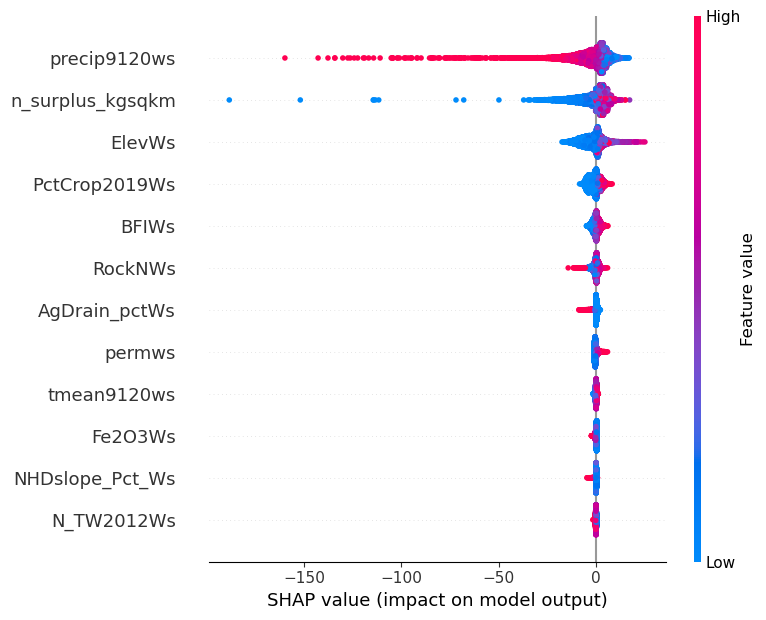

In [ ]:
# Visualize
#shap.summary_plot(shap_values[0], X_test.numpy())
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy()) # works but no feature names
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy(),feature_names=names) # works if generate shape values based on test dataset
#shap.summary_plot(shap_values1[:,:, 0].values, X_full.numpy(),feature_names=names) # works if generate shape values based on test dataset
shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset

#shap.summary_plot(shap_values1[:,:, 0].values, input_data[0:393:].drop(columns=['Viol_Class'])) 

In [ ]:
df_shap.shape

(32326, 10)

In [ ]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
# Save SHAP Results
#filename = 'torch_SHAP_Values_HUC12_All_Observed_sw.parquet'
filename = 'torch_SHAP_Values_HUC12_All_Observed_gw.parquet'

table = pa.Table.from_pandas(df_shap)
pq.write_table(table, future_dir + filename)


# Map Prediction Results


# Zero Inflation Code

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist

class ZeroInflatedPoissonNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Head 1: Probability of Zero-inflation (1 output)
        self.zi_head = nn.Linear(32, 1)
        
        # Head 2: Poisson rate parameter (1 output)
        self.poisson_head = nn.Linear(32, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        
        # Sigmoid for probability between 0 and 1
        pi = torch.sigmoid(self.zi_head(features)) 
        
        # Softplus ensures the lambda (rate) is positive
        rate = F.softplus(self.poisson_head(features)) 
        
        return pi, rate

def zero_inflated_poisson_loss(pi, rate, target):
    """
    Custom Negative Log-Likelihood for Zero-Inflated Poisson
    """
    eps = 1e-8
    
    # Probability of the target being 0
    # P(Y = 0) = pi + (1 - pi) * exp(-rate)
    p_zero = pi + (1 - pi) * torch.exp(-rate)
    
    # P(Y = y) for y > 0
    # P(Y = y) = (1 - pi) * (rate^y * exp(-rate) / y!)
    # In log space: log(1 - pi) + y * log(rate) - rate - log(gamma(y+1))
    p_non_zero_log = torch.log(1 - pi + eps) + target * torch.log(rate + eps) - rate - torch.lgamma(target + 1)
    
    # Mask out zeros vs non-zeros
    zero_mask = (target == 0).float()
    
    # Calculate negative log-likelihood
    nll = -(zero_mask * torch.log(p_zero + eps) + (1 - zero_mask) * p_non_zero_log)
    
    return torch.mean(nll)

In [ ]:
# --- Usage Example ---
model = ZeroInflatedPoissonNetwork(input_dim=10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

x_batch = torch.randn(32, 10)  # Batch of 32, 10 features
y_batch = torch.poisson(torch.ones(32) * 2.0) # Target data with many zeros

pi, rate = model(x_batch)
loss = zero_inflated_poisson_loss(pi, rate, y_batch)

optimizer.zero_grad()
loss.backward()
optimizer.step()